<a href="https://colab.research.google.com/github/HonestyDisciplineConsistency/CSCI323-Group-Project/blob/main/CSCI323_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import required libraries

These libraries are used for loading the dataset, cleaning text, training models, evaluating performance and saving figures/results.

In [18]:
# Basic libraries
import re
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Display helper for notebooks
from IPython.display import display

# Machine learning tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Set reproducibility and output folder

RANDOM_STATE = 42 keeps the train-test split and model results consistent every time the notebook is run.

In [19]:
RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Random state:", RANDOM_STATE)
print("Output folder:", OUTPUT_DIR.resolve())

Random state: 42
Output folder: /content/outputs


## 3. Load the UCI SMS Spam Collection CSV

This notebook only loads the local file uci_sms_spam_collection.csv. The file must be in the same folder as this notebook.

In [20]:
def read_csv_safely(file_path):
    """Read a CSV file using common encodings."""
    encodings = ["utf-8", "latin-1", "ISO-8859-1", "cp1252"]

    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue

    return pd.read_csv(file_path, encoding="latin-1")


def load_uci_sms_dataset():
    """Load only the local UCI SMS Spam Collection CSV file."""
    file_path = Path("uci_sms_spam_collection.csv")

    if not file_path.exists():
        raise FileNotFoundError(
            "uci_sms_spam_collection.csv was not found. "
            "Please upload it into the same folder as this notebook."
        )

    print("Loaded local dataset: uci_sms_spam_collection.csv")
    df = read_csv_safely(file_path)

    if {"label", "message"}.issubset(df.columns):
        return df[["label", "message"]].copy()

    if df.shape[1] >= 2:
        df = df.iloc[:, :2].copy()
        df.columns = ["label", "message"]
        return df

    raise ValueError(
        f"Could not identify label/message columns. Found columns: {list(df.columns)}"
    )


raw_df = load_uci_sms_dataset()

print("Dataset shape:", raw_df.shape)
display(raw_df.head())

print("\nColumns:")
print(list(raw_df.columns))

print("\nLabel counts:")
print(raw_df["label"].value_counts())

Loaded local dataset: uci_sms_spam_collection.csv
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Columns:
['label', 'message']

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


### Explanation

The dataset contains labelled messages. Each message is labelled as either ham or spam, which makes this a supervised binary classification task.

## 4. Check label distribution

This step checks whether the dataset is balanced or imbalanced.

label
ham     4825
spam     747
Name: count, dtype: int64


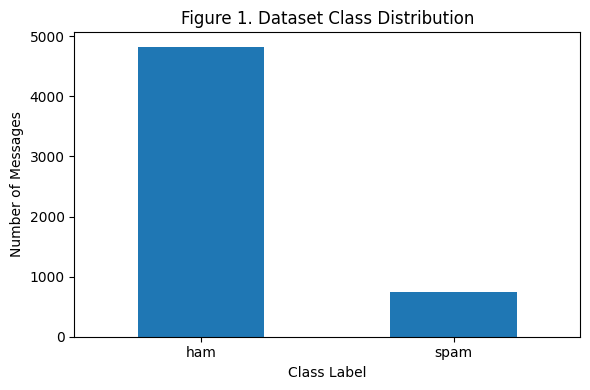

In [21]:
label_counts = raw_df["label"].value_counts()
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")

plt.title("Figure 1. Dataset Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "figure_1_class_distribution.png", dpi=300)
plt.show()

### Explanation

The dataset is imbalanced because ham messages appear more often than spam messages. This is why the evaluation uses precision, recall, F1-score, ROC-AUC and confusion matrix analysis instead of accuracy alone.

## 5. Clean labels and message text

The labels are converted into numbers: `ham = 0` and `spam = 1`. The message text is cleaned by lowercasing, removing URLs, removing email addresses, removing punctuation/symbols, and removing extra spaces.

In [22]:
def clean_text(text):
    """Clean raw message text for spam classification."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)             # remove email addresses
    text = re.sub(r"[^a-zA-Z\s]", " ", text)         # keep letters and spaces only
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text


df = raw_df.copy()
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df["clean_message"] = df["message"].apply(clean_text)

# Remove any rows with invalid labels, if any
df = df.dropna(subset=["label_num"]).copy()
df["label_num"] = df["label_num"].astype(int)

print("Cleaned dataset shape:", df.shape)
print("\nLabel counts after cleaning:")
print(df["label_num"].value_counts())

display(df[["label", "label_num", "message", "clean_message"]].head())

Cleaned dataset shape: (5572, 4)

Label counts after cleaning:
label_num
0    4825
1     747
Name: count, dtype: int64


,label,label_num,message,clean_message
0,ham,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


### Explanation

Text cleaning reduces noise and makes the data more consistent. For example, FREE!!! and free should be treated as the same word.

## 6. Train-test split

The dataset is split into 80% training data and 20% testing data. stratify=y preserves the spam/ham ratio in both sets, and random_state=42 makes the split reproducible.

In [23]:
X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4457
Testing set size: 1115

Training label distribution:
label_num
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Testing label distribution:
label_num
0    0.866368
1    0.133632
Name: proportion, dtype: float64


## 7. Create and train model pipelines

All three models use the same TF-IDF approach so that the comparison is fair.

- Multinomial Naive Bayes: probability-based and suitable for word-based text classification.
- Decision Tree: interpretable and rule-based, but may overfit high-dimensional TF-IDF features.
- Logistic Regression: linear classification model that learns feature weights and works well with sparse TF-IDF text data.

In [24]:
best_nb = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))),
    ("model", MultinomialNB(alpha=0.5))
])

best_dt = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 1))),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        criterion="gini",
        max_depth=20,
        min_samples_leaf=3
    ))
])

best_lr = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))),
    ("model", LogisticRegression(
        C=10.0,
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

print("Training Naive Bayes...")
best_nb.fit(X_train, y_train)

print("Training Decision Tree...")
best_dt.fit(X_train, y_train)

print("Training Logistic Regression...")
best_lr.fit(X_train, y_train)

print("All three models trained successfully.")

Training Naive Bayes...
Training Decision Tree...
Training Logistic Regression...
All three models trained successfully.


## 8. Evaluate models on the test set

The three models are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, classification report and confusion matrix values. Confusion matrix plots are optional and skipped by default to keep the notebook fast.

Naive Bayes
Accuracy     0.977578
Precision         1.0
Recall       0.832215
F1-score     0.908425
ROC-AUC      0.987178
dtype: object

Classification Report:
              precision    recall  f1-score   support

Ham/Non-spam       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix [[TN FP], [FN TP]]:
[[966   0]
 [ 25 124]]


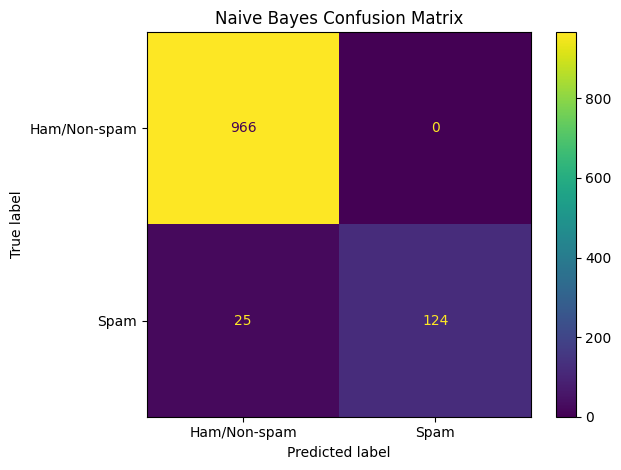

Decision Tree
Accuracy     0.940807
Precision    0.764331
Recall       0.805369
F1-score     0.784314
ROC-AUC      0.874446
dtype: object

Classification Report:
              precision    recall  f1-score   support

Ham/Non-spam       0.97      0.96      0.97       966
        Spam       0.76      0.81      0.78       149

    accuracy                           0.94      1115
   macro avg       0.87      0.88      0.88      1115
weighted avg       0.94      0.94      0.94      1115

Confusion Matrix [[TN FP], [FN TP]]:
[[929  37]
 [ 29 120]]


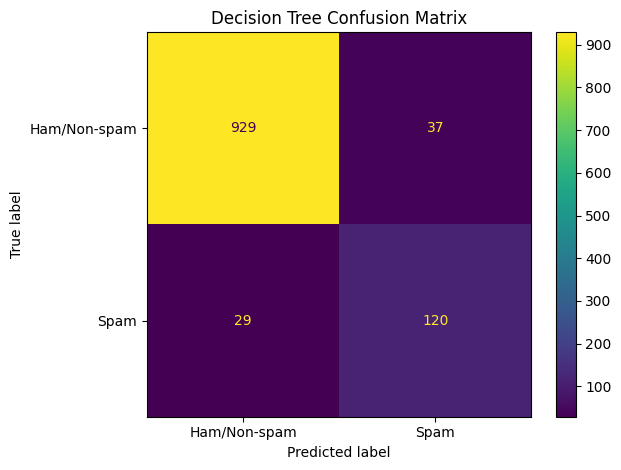

Logistic Regression
Accuracy     0.981166
Precision    0.977612
Recall       0.879195
F1-score     0.925795
ROC-AUC      0.985615
dtype: object

Classification Report:
              precision    recall  f1-score   support

Ham/Non-spam       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix [[TN FP], [FN TP]]:
[[963   3]
 [ 18 131]]


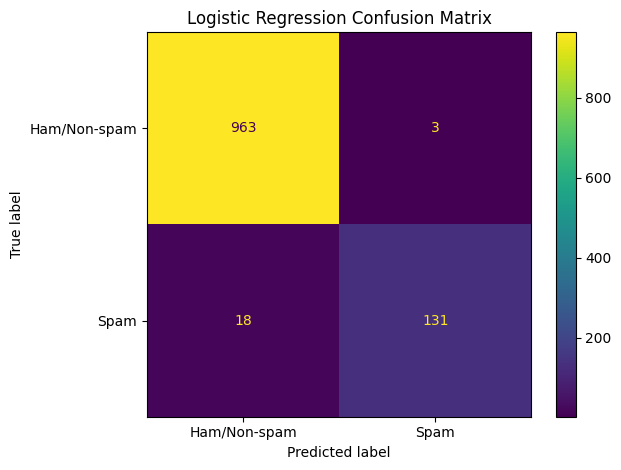

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.977578,1.000000,0.832215,0.908425,0.987178
1,Decision Tree,0.940807,0.764331,0.805369,0.784314,0.874446
2,Logistic Regression,0.981166,0.977612,0.879195,0.925795,0.985615


,Model,TN,FP,FN,TP
0,Naive Bayes,966,0,25,124
1,Decision Tree,929,37,29,120
2,Logistic Regression,963,3,18,131


In [25]:
PLOT_CONFUSION_MATRICES = True


def get_spam_probability(model, X_values):
    """Return predicted probability for class 1 = spam."""
    probabilities = model.predict_proba(X_values)

    # The models are sklearn Pipelines, so class labels are stored in the final model step.
    class_list = list(model.named_steps["model"].classes_)
    spam_index = class_list.index(1)

    return probabilities[:, spam_index]


def evaluate_model(model_name, model, X_test, y_test):
    """
    Evaluate a trained model using accuracy, precision, recall,
    F1-score, ROC-AUC, classification report, and confusion matrix.
    """
    y_pred = model.predict(X_test)
    y_proba = get_spam_probability(model, X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(pd.Series(metrics).drop("Model"))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Ham/Non-spam", "Spam"]
    ))

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix [[TN FP], [FN TP]]:")
    print(cm)

    if PLOT_CONFUSION_MATRICES:
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Ham/Non-spam", "Spam"]
        )

        disp.plot(values_format="d")
        plt.title(f"{model_name} Confusion Matrix")
        plt.tight_layout()

        file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
        plt.savefig(OUTPUT_DIR / file_name, dpi=300)

        plt.show()

    return metrics, y_pred, y_proba, cm


# Evaluate all three models
nb_metrics, nb_pred, nb_proba, nb_cm = evaluate_model("Naive Bayes", best_nb, X_test, y_test)
dt_metrics, dt_pred, dt_proba, dt_cm = evaluate_model("Decision Tree", best_dt, X_test, y_test)
lr_metrics, lr_pred, lr_proba, lr_cm = evaluate_model("Logistic Regression", best_lr, X_test, y_test)

# Create model comparison table
results_df = pd.DataFrame([nb_metrics, dt_metrics, lr_metrics])
display(results_df)
results_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)

# Create confusion matrix summary table
confusion_summary_df = pd.DataFrame([
    {"Model": "Naive Bayes", "TN": nb_cm[0, 0], "FP": nb_cm[0, 1], "FN": nb_cm[1, 0], "TP": nb_cm[1, 1]},
    {"Model": "Decision Tree", "TN": dt_cm[0, 0], "FP": dt_cm[0, 1], "FN": dt_cm[1, 0], "TP": dt_cm[1, 1]},
    {"Model": "Logistic Regression", "TN": lr_cm[0, 0], "FP": lr_cm[0, 1], "FN": lr_cm[1, 0], "TP": lr_cm[1, 1]}
])

display(confusion_summary_df)
confusion_summary_df.to_csv(OUTPUT_DIR / "confusion_matrix_summary.csv", index=False)

### Explanation

This table is the main evidence for the report's test-set results. It compares Naive Bayes, Decision Tree, and Logistic Regression using the same dataset, split and TF-IDF features.

## 9. Model comparison chart

This chart can be used as Figure 2 in the report or presentation.

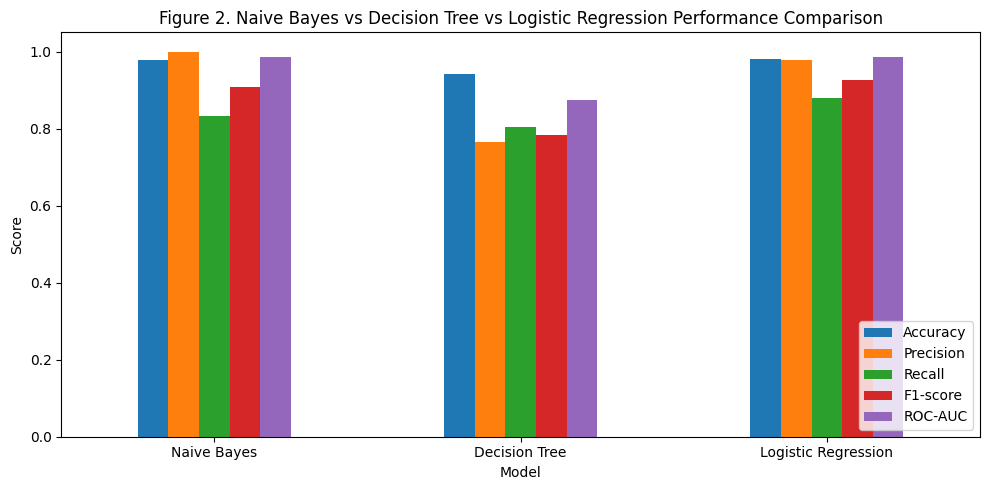

In [26]:
PLOT_MODEL_COMPARISON = True

if PLOT_MODEL_COMPARISON:
    plot_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

    ax = results_df.set_index("Model")[plot_metrics].plot(kind="bar", figsize=(10, 5))
    plt.title("Figure 2. Naive Bayes vs Decision Tree vs Logistic Regression Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figure_2_model_comparison.png", dpi=300)
    plt.show()
else:
    print("Model comparison chart skipped. Set PLOT_MODEL_COMPARISON = True to generate it.")

## 10. ROC curve comparison

ROC-AUC is already calculated in the results table. The ROC curve is useful for visualising how well each model separates spam from ham.

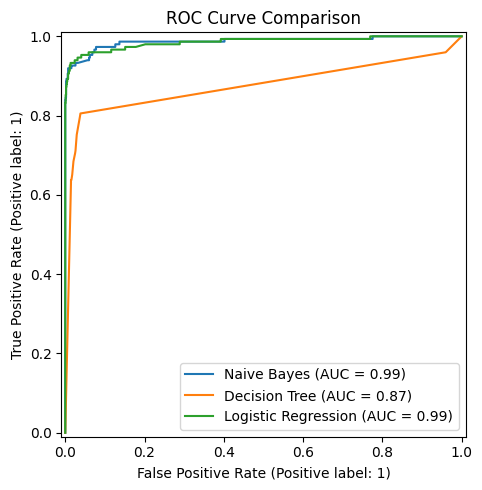

In [27]:
PLOT_ROC_CURVE = True

if PLOT_ROC_CURVE:
    fig, ax = plt.subplots(figsize=(7, 5))
    RocCurveDisplay.from_predictions(y_test, nb_proba, name="Naive Bayes", ax=ax)
    RocCurveDisplay.from_predictions(y_test, dt_proba, name="Decision Tree", ax=ax)
    RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=ax)
    plt.title("ROC Curve Comparison")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "roc_curve_comparison.png", dpi=300)
    plt.show()
else:
    print("ROC curve plot skipped. ROC-AUC scores are shown in the results table.")

## 11. Cross-validation stability

Cross-validation checks whether each model performs consistently across different data splits. A 3-fold setup is used here to keep the notebook fast while still giving a stability check.

In [28]:
scoring = ["accuracy", "precision", "recall", "f1"]
cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

models_for_cv = [
    ("Naive Bayes", best_nb),
    ("Decision Tree", best_dt),
    ("Logistic Regression", best_lr)
]

for model_name, model in models_for_cv:
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv_fast,
        scoring=scoring,
        n_jobs=1
    )

    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Naive Bayes,0.975095,0.001459,0.991906,0.002901,0.821080,0.009264,0.898423,0.006262
1,Decision Tree,0.939869,0.007258,0.768753,0.039472,0.792630,0.006633,0.780066,0.022063
2,Logistic Regression,0.977114,0.001106,0.964473,0.004938,0.861181,0.009772,0.909859,0.004919


## 12. Feature interpretation

This section helps explain why the models make certain predictions. Naive Bayes uses log-probability differences, Decision Tree uses feature importance, and Logistic Regression uses learned feature weights.

In [29]:
def show_naive_bayes_top_words(nb_model, top_n=20):
    vectorizer = nb_model.named_steps["tfidf"]
    model = nb_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    class_list = list(model.classes_)
    ham_index = class_list.index(0)
    spam_index = class_list.index(1)

    spam_strength = model.feature_log_prob_[spam_index] - model.feature_log_prob_[ham_index]

    top_spam_indices = np.argsort(spam_strength)[-top_n:][::-1]
    top_ham_indices = np.argsort(spam_strength)[:top_n]

    top_spam = pd.DataFrame({
        "Word": feature_names[top_spam_indices],
        "Spam Association Score": spam_strength[top_spam_indices]
    })

    top_ham = pd.DataFrame({
        "Word": feature_names[top_ham_indices],
        "Ham Association Score": spam_strength[top_ham_indices]
    })

    return top_spam, top_ham


def show_decision_tree_top_features(dt_model, top_n=20):
    vectorizer = dt_model.named_steps["tfidf"]
    model = dt_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[-top_n:][::-1]

    return pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Importance": importances[top_indices]
    })


def show_logistic_regression_top_words(lr_model, top_n=20):
    vectorizer = lr_model.named_steps["tfidf"]
    model = lr_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefficients = model.coef_[0]

    top_spam_indices = np.argsort(coefficients)[-top_n:][::-1]
    top_ham_indices = np.argsort(coefficients)[:top_n]

    top_spam = pd.DataFrame({
        "Word": feature_names[top_spam_indices],
        "Logistic Regression Spam Weight": coefficients[top_spam_indices]
    })

    top_ham = pd.DataFrame({
        "Word": feature_names[top_ham_indices],
        "Logistic Regression Ham Weight": coefficients[top_ham_indices]
    })

    return top_spam, top_ham


top_spam_words, top_ham_words = show_naive_bayes_top_words(best_nb, top_n=20)
dt_top_features = show_decision_tree_top_features(best_dt, top_n=20)
lr_top_spam_words, lr_top_ham_words = show_logistic_regression_top_words(best_lr, top_n=20)

print("Top words associated with spam according to Naive Bayes:")
display(top_spam_words)

print("Top words associated with ham/non-spam according to Naive Bayes:")
display(top_ham_words)

print("Top Decision Tree features:")
display(dt_top_features)

print("Top words associated with spam according to Logistic Regression:")
display(lr_top_spam_words)

print("Top words associated with ham/non-spam according to Logistic Regression:")
display(lr_top_ham_words)

top_spam_words.to_csv(OUTPUT_DIR / "naive_bayes_top_spam_words.csv", index=False)
top_ham_words.to_csv(OUTPUT_DIR / "naive_bayes_top_ham_words.csv", index=False)
dt_top_features.to_csv(OUTPUT_DIR / "decision_tree_top_features.csv", index=False)
lr_top_spam_words.to_csv(OUTPUT_DIR / "logistic_regression_top_spam_words.csv", index=False)
lr_top_ham_words.to_csv(OUTPUT_DIR / "logistic_regression_top_ham_words.csv", index=False)

Top words associated with spam according to Naive Bayes:


,Word,Spam Association Score
0,claim,4.332640
1,prize,4.107252
2,tone,3.618591
3,guaranteed,3.596435
4,ppm,3.593748
5,cs,3.533275
6,pobox,3.493716
7,ringtone,3.427207
8,landline,3.400033
9,awarded,3.302511


Top words associated with ham/non-spam according to Naive Bayes:


,Word,Ham Association Score
0,gt,-3.737682
1,lt,-3.720260
2,lt gt,-3.620242
3,lor,-3.489985
4,later,-3.428207
5,home,-3.317215
6,ll,-3.316685
7,ok,-3.303974
8,come,-3.253290
9,da,-3.225508


Top Decision Tree features:


,Feature,Importance
0,txt,0.141016
1,free,0.114948
2,claim,0.107796
3,box,0.074717
4,reply,0.068429
5,service,0.064627
6,mobile,0.047640
7,text,0.042654
8,urgent,0.034544
9,won,0.032876


Top words associated with spam according to Logistic Regression:


,Word,Logistic Regression Spam Weight
0,txt,8.428345
1,mobile,7.478561
2,claim,6.723535
3,uk,6.221411
4,reply,5.886436
5,prize,5.320556
6,won,5.114305
7,ringtone,5.032428
8,service,4.789522
9,pobox,4.712747


Top words associated with ham/non-spam according to Logistic Regression:


,Word,Logistic Regression Ham Weight
0,ok,-3.050443
1,ll,-3.015227
2,home,-2.850609
3,lt,-2.749730
4,gt,-2.710246
5,hey,-2.698567
6,later,-2.516308
7,sorry,-2.442298
8,da,-2.364405
9,lt gt,-2.355279


### Explanation

These features support the report discussion. Spam words are mostly linked to prizes, claims, phone services and rewards, while ham words are more conversational. Logistic Regression adds another useful view by showing which TF-IDF features receive positive or negative classification weights.

## 13. Error analysis

This checks false positives and false negatives.

- False positive: ham wrongly classified as spam.
- False negative: spam wrongly classified as ham.

In [30]:
test_analysis = pd.DataFrame({
    "message": df.loc[X_test.index, "message"].values,
    "clean_message": X_test.values,
    "true_label": y_test.values,
    "nb_pred": nb_pred,
    "dt_pred": dt_pred,
    "lr_pred": lr_pred,
    "nb_spam_probability": nb_proba,
    "dt_spam_probability": dt_proba,
    "lr_spam_probability": lr_proba
})


def show_errors(model_pred_col, model_name, max_examples=5):
    false_positives = test_analysis[
        (test_analysis["true_label"] == 0) & (test_analysis[model_pred_col] == 1)
    ]

    false_negatives = test_analysis[
        (test_analysis["true_label"] == 1) & (test_analysis[model_pred_col] == 0)
    ]

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"False positives: {len(false_positives)}")
    display(false_positives[["message", "true_label", model_pred_col]].head(max_examples))

    print(f"False negatives: {len(false_negatives)}")
    display(false_negatives[["message", "true_label", model_pred_col]].head(max_examples))


show_errors("nb_pred", "Naive Bayes")
show_errors("dt_pred", "Decision Tree")
show_errors("lr_pred", "Logistic Regression")

test_analysis.to_csv(OUTPUT_DIR / "test_error_analysis.csv", index=False)

Naive Bayes
False positives: 0


,message,true_label,nb_pred


False negatives: 25


,message,true_label,nb_pred
23,You are now unsubscribed all services. Get ton...,1,0
44,FreeMsg Hey there darling it's been 3 week's n...,1,0
83,Guess what! Somebody you know secretly fancies...,1,0
196,ringtoneking 84484,1,0
219,Sorry I missed your call let's talk when you h...,1,0


Decision Tree
False positives: 37


...

,message,true_label,dt_pred
23,You are now unsubscribed all services. Get ton...,1,0
83,Guess what! Somebody you know secretly fancies...,1,0
185,"This is the 2nd attempt to contract U, you hav...",1,0
196,ringtoneking 84484,1,0
198,"If you don't, your prize will go to another cu...",1,0


Logistic Regression
False positives: 3


,message,true_label,lr_pred
197,.Please charge my mobile when you get up in mo...,0,1
380,K..u also dont msg or reply to his msg..,0,1
556,Msg me when rajini comes.,0,1


False negatives: 18


,message,true_label,lr_pred
44,FreeMsg Hey there darling it's been 3 week's n...,1,0
122,Dear Voucher Holder 2 claim your 1st class air...,1,0
196,ringtoneking 84484,1,0
219,Sorry I missed your call let's talk when you h...,1,0
232,Rock yr chik. Get 100's of filthy films &XXX p...,1,0


## 14. Marginal case testing

Marginal cases are messages that are difficult to classify because they contain features of both spam and ham.

In [31]:
marginal_cases = [
    "Congratulations, you have won a free voucher. Claim your reward now.",
    "Hi, can you send me the report by tonight? It is urgent.",
    "Your account requires verification. Please login to confirm your details.",
    "Limited time discount available for selected customers only.",
    "Dear user, your mailbox storage is almost full. Click here to upgrade.",
    "Please review the attached invoice and confirm payment.",
]

marginal_df = pd.DataFrame({"message": marginal_cases})
marginal_df["clean_message"] = marginal_df["message"].apply(clean_text)

marginal_df["Naive Bayes Prediction"] = best_nb.predict(marginal_df["clean_message"])
marginal_df["Naive Bayes Spam Probability"] = get_spam_probability(best_nb, marginal_df["clean_message"])

marginal_df["Decision Tree Prediction"] = best_dt.predict(marginal_df["clean_message"])
marginal_df["Decision Tree Spam Probability"] = get_spam_probability(best_dt, marginal_df["clean_message"])

marginal_df["Logistic Regression Prediction"] = best_lr.predict(marginal_df["clean_message"])
marginal_df["Logistic Regression Spam Probability"] = get_spam_probability(best_lr, marginal_df["clean_message"])

marginal_df["Naive Bayes Prediction"] = marginal_df["Naive Bayes Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})
marginal_df["Decision Tree Prediction"] = marginal_df["Decision Tree Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})
marginal_df["Logistic Regression Prediction"] = marginal_df["Logistic Regression Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})

display(marginal_df)
marginal_df.to_csv(OUTPUT_DIR / "marginal_case_predictions.csv", index=False)

,message,clean_message,Naive Bayes Prediction,Naive Bayes Spam Probability,Decision Tree Prediction,Decision Tree Spam Probability,Logistic Regression Prediction,Logistic Regression Spam Probability
0,"Congratulations, you have won a free voucher. ...",congratulations you have won a free voucher cl...,Spam,0.979234,Spam,1.000000,Spam,0.968664
1,"Hi, can you send me the report by tonight? It ...",hi can you send me the report by tonight it is...,Ham/Non-spam,0.050026,Spam,0.682646,Ham/Non-spam,0.106282
2,Your account requires verification. Please log...,your account requires verification please logi...,Ham/Non-spam,0.133509,Ham/Non-spam,0.087472,Ham/Non-spam,0.040840
3,Limited time discount available for selected c...,limited time discount available for selected c...,Ham/Non-spam,0.401526,Ham/Non-spam,0.087472,Ham/Non-spam,0.108920
4,"Dear user, your mailbox storage is almost full...",dear user your mailbox storage is almost full ...,Spam,0.534836,Spam,1.000000,Ham/Non-spam,0.266580
5,Please review the attached invoice and confirm...,please review the attached invoice and confirm...,Ham/Non-spam,0.124534,Ham/Non-spam,0.087472,Ham/Non-spam,0.028371


### Explanation

These marginal cases support the report discussion. Obvious spam is usually detected well, but formal phishing-style messages such as account verification can be harder because they may look like normal communication.